In [55]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import os

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898|21' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

In [62]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

EXCLUDE = []
MPKI_MIN = 1.0

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, mpki_min=MPKI_MIN) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items() if reference_mpki[w] >= mpki_min and w not in EXCLUDE }
    return out

In [63]:
baseline_stats = read_csv_file('baseline_core8_lru.csv')
reference_mpki = { w: stats['llc_mpki'] for (w,stats) in baseline_stats.items() }
print(reference_mpki)

{'bwaves': 13.6, 'xz': 1.134977973568282, 'gcc': 17.799999999999997, 'mcf': 17.37474850753653, 'leela': 0.011799999999999998, 'xalancbmk': 1.988731932290648, 'omnetpp': 10.5, 'fotonik3d': 15.762351072279587, 'cam4': 4.882075747786654, 'pop2': 3.282486662976796, 'imagick': 0.03910000000000001, 'x264': 0.19786813967573916, 'exchange2': 0.00014, 'perlbench': 0.0669, 'roms': 7.3599999999999985, 'nab': 0.1699985293735997, 'cactuBSSN': 7.150000000000002, 'deepsjeng': 0.27699999999999997, 'lbm': 27.499999999999996, 'wrf': 11.8, 'cf': 2.271245200219419, 'bfs': 2.1, 'bc': 21.0, 'mis': 2.11, 'pagerankdelta': 15.9, 'components': 2.11, 'components-shortcut': 2.11, 'pagerank': 44.8, 'triangle': 2.11, 'bellmanford': 19.8, 'bfs-bitvector': 2.1, 'bfscc': 2.11, 'radii': 2.11, 'facesim': 10.600000000000001, 'fluidanimate': 4.93, 'raytrace': 3.4299999999999997, 'streamcluster': 12.3, 'canneal': 4.9099949083344665}


In [64]:
# SOL stats:
tCCD_S_WR = 8

def compute_sol_speedup(build: str):
    stats = read_csv_file(f'{build}.csv')
    out = []
    for w in stats:
        if reference_mpki[w] < MPKI_MIN:
            continue
        
        tot_cycles = stats[w]['dram_cycles']
        write_cycles = stats[w]['write_cycles']
        ideal_write_cycles = stats[w]['num_writes'] * tCCD_S_WR

        if write_cycles == 0:
            continue
        
        ideal_cycles = tot_cycles - write_cycles + ideal_write_cycles
        out.append(tot_cycles/ideal_cycles)
    out.append(sp.stats.gmean(out))

    return out[-1], max(out)

print('SOL speedup:', compute_sol_speedup('baseline_core8_lru'))

SOL speedup: (1.1729236006391166, 1.323965720940783)


In [65]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, labels: list, color_list: list, negate=False, percentage=False, plot_best_of_all=False):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki)

    n_labels = len(builds)
    if plot_best_of_all:
        n_labels += 1
    
    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 3.4)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / n_labels
    off = 0

    gmean_list = []

    best_of_all = [-100 for _ in baseline_ipc_list]
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        if i == 0:
            continue
        X = np.arange(len(ipc_list)+1)
        
        Y = [ ipc_list[w]/baseline_ipc_list[w] for w in ipc_list ]

        best_of_all = [max(max(best_of_all[i], Y[i]), 1.0) for i in range(len(Y))]
        
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        if percentage:
            Y = (Y-1) * 100
        if negate:
            Y = -Y
            
        gmean_list.append(Y[-1])
        ax.bar(X+off, Y, width, color=color_list[i-1], label=labels[i-1], zorder=3, edgecolor='k')
        off += width

    if plot_best_of_all:
        best_of_all.append(sp.stats.gmean(best_of_all))
        best_of_all = np.array(best_of_all)
        if percentage:
            best_of_all = (best_of_all-1) * 100
        if negate:
            best_of_all = best_of_all

        gmean_list.append(best_of_all[-1])
        ax.bar(X+off, best_of_all, width, color=C6, label='BoA', zorder=3, edgecolor='k')
    
    # Setup anything else that is remaining:
    workloads = [w for w in baseline_ipc_list]
    workloads.append('gmean')
    
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(X + (len(builds)-1)/2 * width, workloads, rotation=30, ha='right', fontsize=12)
    ax.grid(visible=True, axis='y', zorder=0)
    
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=n_labels, loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')

    if plot_best_of_all:
        print(f'{stat_name} GMEAN of BoA\t{gmean_list[-1]:.3f}')
    print('----------------------------')

In [66]:
for ddr in ['ddr3', 'ddr5']:
    plot_relative_stat(f'plots/{ddr}_results.pdf',
                       [f'{ddr}_core8_lru_close', f'{ddr}_core8_lru_open', f'{ddr}_core8_lru_hybrid'],
                       'ipc',
                       'Speedup (%)',
                       ['Open-Page', 'Soft Close-Page', 'Close-Page, tWTR = 0', 'Open-Page, tWTR=0', 'Soft Close-Page, tWTR = 0'],
                       [C1, C2, C3, C4, C5],
                       percentage=True)

FileNotFoundError: [Errno 2] No such file or directory: 'ddr3_core8_lru_close.csv'

ipc GMEAN of vwq_core8_lru	0.741
ipc GMEAN of wcache_core8_lru_repl_only	0.862
ipc GMEAN of wcache_core8_lru	0.182
ipc GMEAN of BoA	2.093
----------------------------
ipc GMEAN of wcache_core8_srrip_repl_only	0.713
ipc GMEAN of wcache_core8_srrip	-0.347
ipc GMEAN of BoA	1.809
----------------------------


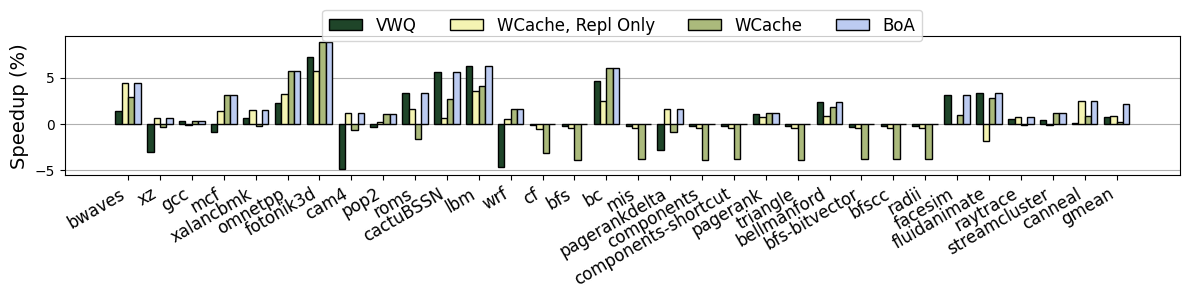

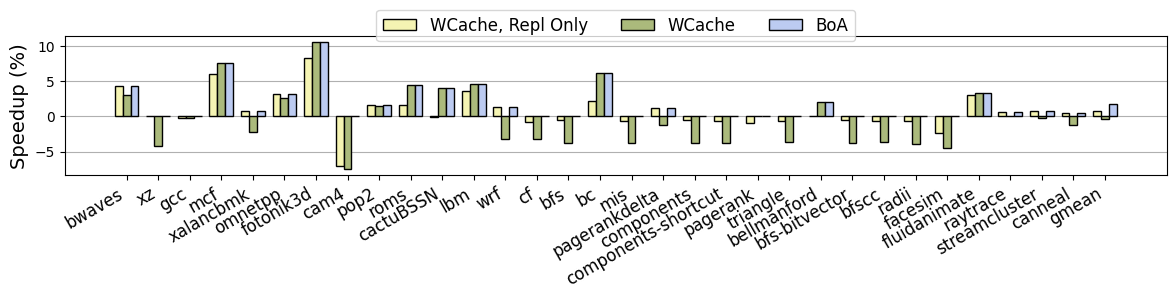

In [67]:
# Main evaluations:
plot_relative_stat('plots/main_evals_lru.pdf',
                   ['baseline_core8_lru', 'vwq_core8_lru', 'wcache_core8_lru_repl_only', 'wcache_core8_lru'],
                   'ipc',
                   'Speedup (%)',
                   ['VWQ', 'WCache, Repl Only', 'WCache'],
                   [C3, C1, C4],
                   percentage=True, plot_best_of_all=True)
plot_relative_stat('plots/main_evals_srrip.pdf',
                   ['baseline_core8_srrip', 'wcache_core8_srrip_repl_only', 'wcache_core8_srrip'],
                   'ipc',
                   'Speedup (%)',
                   ['WCache, Repl Only', 'WCache'],
                   [C1, C4],
                   percentage=True, plot_best_of_all=True)

In [68]:
# Sensitivity results:
plot_relative_stat('plots/wcache_lookup_sens.pdf',
                   ['baseline_core8_lru', 'wcache_sens_lookup_2', 'wcache_sens_lookup_4', 'wcache_sens_lookup_8', 'wcache_sens_lookup_12', 'wcache_sens_lookup_16'],
                   'ipc',
                   'Speedup (%)',
                   ['2 ways', '4 ways', '8 ways', '12 ways', '16 ways'],
                   [C1,C2,C3,C4,C5],
                   percentage=True, plot_best_of_all=True)

plot_relative_stat('plots/wcache_sampling_sens.pdf',
                   ['baseline_core8_lru', 'wcache_sens_sampling_8', 'wcache_sens_sampling_16', 'wcache_sens_sampling_32', 'wcache_sens_sampling_64', 'wcache_sens_sampling_128'],
                   'ipc',
                   'Speedup (%)',
                   ['8 sampled sets', '16 sampled sets', '32 sampled sets', '64 sampled sets', '128 sampled sets'],
                   [C1,C2,C3,C4,C5],
                   percentage=True)

FileNotFoundError: [Errno 2] No such file or directory: 'wcache_sens_lookup_2.csv'